# ch211 — Multivariable Functions

**Part VII: Calculus**

---

## 1. Functions of Multiple Variables

A multivariable function maps a vector input to one or more outputs:

- **Scalar-valued**: f: ℝⁿ → ℝ (loss functions, energy functions)
- **Vector-valued**: f: ℝⁿ → ℝᵐ (neural network layers, transformations)

We have been working with scalar-valued functions *(ch209–210)*. Understanding vector-valued functions is essential for the Jacobian and backpropagation *(ch215–216)*.

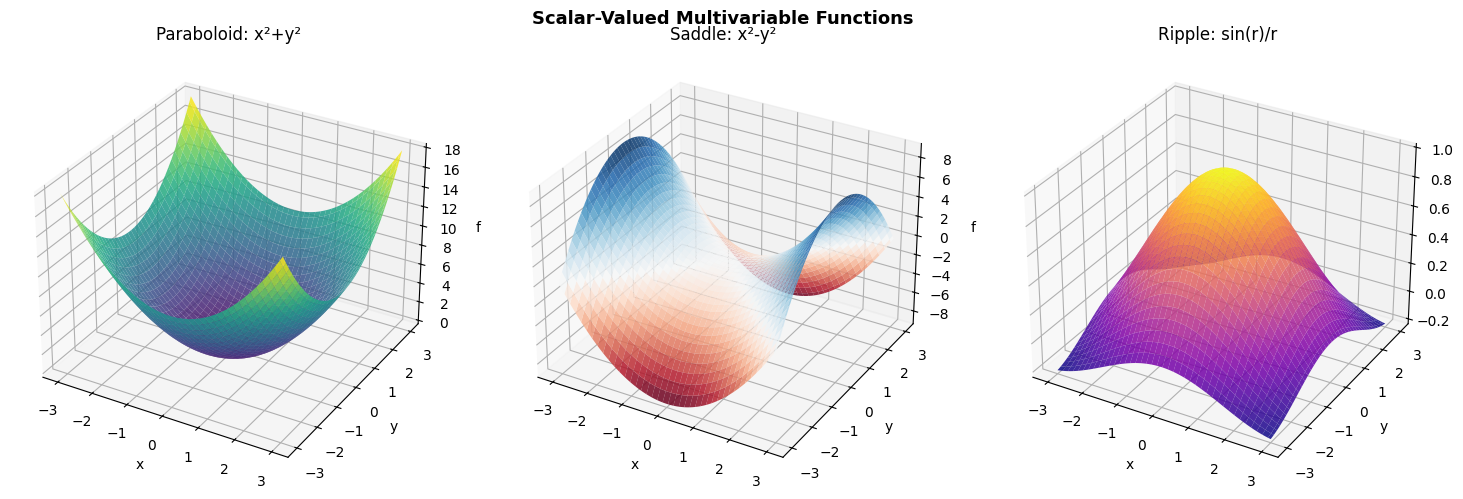

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Scalar-valued: f(x,y,z) = x^2 + y^2 + z^2 (sphere level sets)
# Vector-valued: F(x,y) = [sin(x)*cos(y), cos(x)*sin(y)] (2D → 2D)

# Visualize several scalar-valued functions and their properties
fig = plt.figure(figsize=(15, 5))

funcs = [
    ('Paraboloid: x²+y²',  lambda x,y: x**2 + y**2,    'viridis'),
    ('Saddle: x²-y²',       lambda x,y: x**2 - y**2,    'RdBu'),
    ('Ripple: sin(r)/r',    lambda x,y: np.sinc(np.sqrt(x**2+y**2)/np.pi), 'plasma'),
]

x = np.linspace(-3, 3, 80)
y = np.linspace(-3, 3, 80)
X, Y = np.meshgrid(x, y)

for i, (title, fn, cmap) in enumerate(funcs):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    Z = fn(X, Y)
    ax.plot_surface(X, Y, Z, cmap=cmap, alpha=0.85, linewidth=0)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('f')

plt.suptitle('Scalar-Valued Multivariable Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [2]:
# Vector-valued function: a neural network's forward pass
# Input: x ∈ R^D, Output: y ∈ R^K
# f(x) = W2 * ReLU(W1 * x + b1) + b2

np.random.seed(1)

def relu(z): return np.maximum(0, z)

class TwoLayerNet:
    def __init__(self, D_in, H, D_out):
        self.W1 = np.random.randn(H, D_in) * 0.1
        self.b1 = np.zeros(H)
        self.W2 = np.random.randn(D_out, H) * 0.1
        self.b2 = np.zeros(D_out)
    
    def forward(self, x):
        self.z1 = self.W1 @ x + self.b1   # linear
        self.a1 = relu(self.z1)             # activation
        self.z2 = self.W2 @ self.a1 + self.b2  # output
        return self.z2

D_in, H, D_out = 4, 8, 3
net = TwoLayerNet(D_in, H, D_out)

x_sample = np.array([1.0, -0.5, 2.0, 0.3])
out = net.forward(x_sample)

print("Two-layer network as a vector-valued function:")
print(f"  Input dimension:  {D_in}")
print(f"  Hidden dimension: {H}")
print(f"  Output dimension: {D_out}")
print(f"  Input:  {x_sample}")
print(f"  Output: {np.round(out, 4)}")
print()
print("  f: R^4 → R^3 — this is a vector-valued multivariable function.")
print("  The Jacobian of f is a 3x4 matrix (ch215).")

# Jacobian via finite differences
h = 1e-7
J = np.zeros((D_out, D_in))
for j in range(D_in):
    x_plus  = x_sample.copy(); x_plus[j]  += h
    x_minus = x_sample.copy(); x_minus[j] -= h
    J[:, j] = (net.forward(x_plus) - net.forward(x_minus)) / (2*h)

print(f"\n  Jacobian matrix (shape {J.shape}):")
print(np.round(J, 4))


Two-layer network as a vector-valued function:
  Input dimension:  4
  Hidden dimension: 8
  Output dimension: 3
  Input:  [ 1.  -0.5  2.   0.3]
  Output: [-0.0604 -0.038   0.0266]

  f: R^4 → R^3 — this is a vector-valued multivariable function.
  The Jacobian of f is a 3x4 matrix (ch215).

  Jacobian matrix (shape (3, 4)):
[[-0.0063  0.0265 -0.0215  0.0069]
 [-0.01    0.0079 -0.0122  0.0009]
 [ 0.0133 -0.0069  0.0072 -0.0148]]


## 2. Level Sets and Contours

The **level set** of f at value c is the set of all x where f(x) = c. For f: ℝ² → ℝ, these are contour lines. For f: ℝ³ → ℝ, they are surfaces (e.g., isobaric surfaces in weather maps).

The gradient is always perpendicular to level sets *(ch209)*.

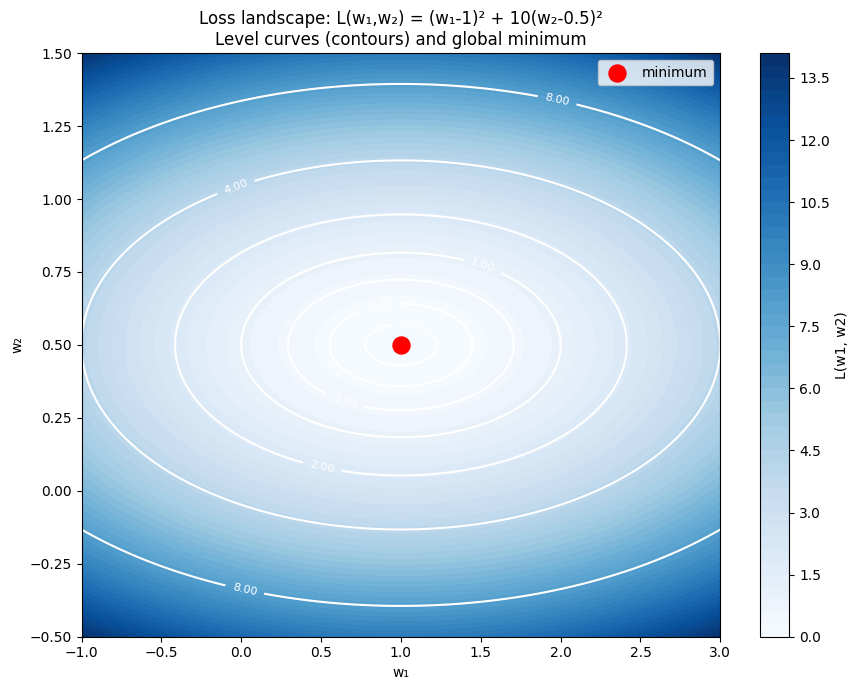

The elongated contours (high condition number) mean gradient descent
will oscillate in the steep direction — motivating adaptive optimizers.


In [3]:
# Loss landscape for a simple 2-parameter model
# L(w1, w2) = (w1 - 1)^2 + 10*(w2 - 0.5)^2  (elongated bowl)
L = lambda w1, w2: (w1 - 1)**2 + 10*(w2 - 0.5)**2

w1 = np.linspace(-1, 3, 200)
w2 = np.linspace(-0.5, 1.5, 200)
W1, W2 = np.meshgrid(w1, w2)
Z = L(W1, W2)

fig, ax = plt.subplots(figsize=(9, 7))
levels = [0.05, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0]
cs = ax.contourf(W1, W2, Z, levels=50, cmap='Blues')
ct = ax.contour(W1, W2, Z, levels=levels, colors='white', linewidths=1.5)
plt.colorbar(cs, ax=ax, label='L(w1, w2)')
ax.clabel(ct, fmt='%.2f', fontsize=8)
ax.scatter([1.0], [0.5], color='red', s=150, zorder=8, label='minimum')
ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
ax.set_title('Loss landscape: L(w₁,w₂) = (w₁-1)² + 10(w₂-0.5)²\nLevel curves (contours) and global minimum')
ax.legend()
plt.tight_layout()
plt.show()

print("The elongated contours (high condition number) mean gradient descent")
print("will oscillate in the steep direction — motivating adaptive optimizers.")


## 3. Summary

- Multivariable functions map vectors to scalars or vectors
- Scalar-valued: f: ℝⁿ → ℝ — has a gradient (vector of partial derivatives)
- Vector-valued: f: ℝⁿ → ℝᵐ — has a Jacobian (matrix of partial derivatives)
- Level sets of scalar-valued functions are the contour curves/surfaces
- The elongation of loss contours determines optimization difficulty

---

## 4. Forward References

The Jacobian of a vector-valued function is formalized in ch215 — Chain Rule, where it appears as the matrix that connects input and output gradients. The shape of the loss landscape (elongated vs circular contours) is quantified by the Hessian in ch217 — Second Derivatives and motivates the discussion of adaptive optimizers in ch291 — Optimization Methods (Part IX).